In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
%matplotlib inline

import os

os.listdir("./data")

['movies.dat', 'users.dat', 'README', 'ratings.dat']

In [2]:
ratings = pd.read_csv('data/ratings.dat', sep='::', engine='python', 
                      names=['userId', 'movieId', 'rating', 'timestamp'])

movies = pd.read_csv('data/movies.dat', sep='::', engine='python', encoding='latin-1',
                     names=['movieId', 'title', 'genres'])

print(ratings.shape)
print(movies.shape)
print(ratings.head())
print(movies.head())

(1000209, 4)
(3883, 3)
   userId  movieId  rating  timestamp
0       1     1193       5  978300760
1       1      661       3  978302109
2       1      914       3  978301968
3       1     3408       4  978300275
4       1     2355       5  978824291
   movieId                               title                        genres
0        1                    Toy Story (1995)   Animation|Children's|Comedy
1        2                      Jumanji (1995)  Adventure|Children's|Fantasy
2        3             Grumpier Old Men (1995)                Comedy|Romance
3        4            Waiting to Exhale (1995)                  Comedy|Drama
4        5  Father of the Bride Part II (1995)                        Comedy


In [3]:
df = pd.merge(ratings, movies, how="left", on="movieId")
print(df.head())

   userId  movieId  rating  timestamp                                   title  \
0       1     1193       5  978300760  One Flew Over the Cuckoo's Nest (1975)   
1       1      661       3  978302109        James and the Giant Peach (1996)   
2       1      914       3  978301968                     My Fair Lady (1964)   
3       1     3408       4  978300275                  Erin Brockovich (2000)   
4       1     2355       5  978824291                    Bug's Life, A (1998)   

                         genres  
0                         Drama  
1  Animation|Children's|Musical  
2               Musical|Romance  
3                         Drama  
4   Animation|Children's|Comedy  


/tmp/ipykernel_183244/1173979252.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=df, palette='viridis')


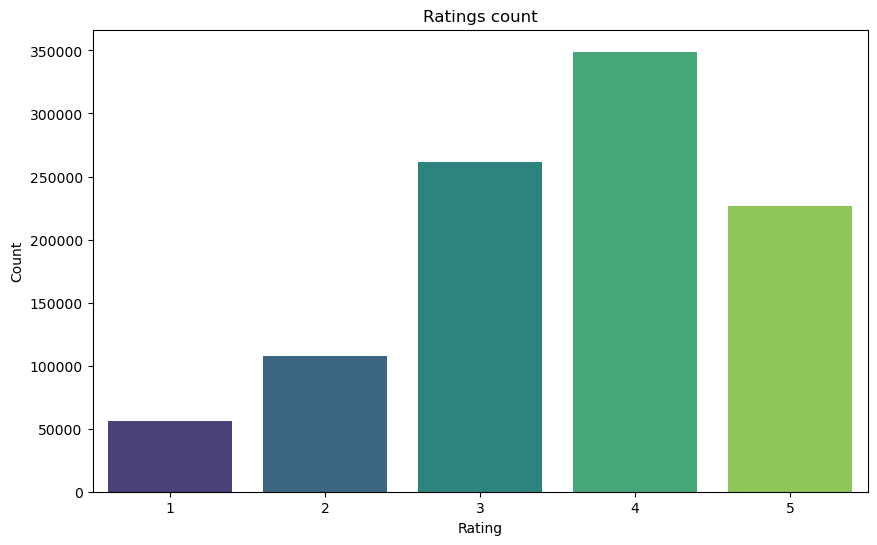

In [4]:
plt.figure(figsize=(10, 6))
sns.countplot(x='rating', data=df, palette='viridis')
plt.title('Ratings count')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

/tmp/ipykernel_183244/946085683.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_movies.index, x=top_movies.values, palette='magma')


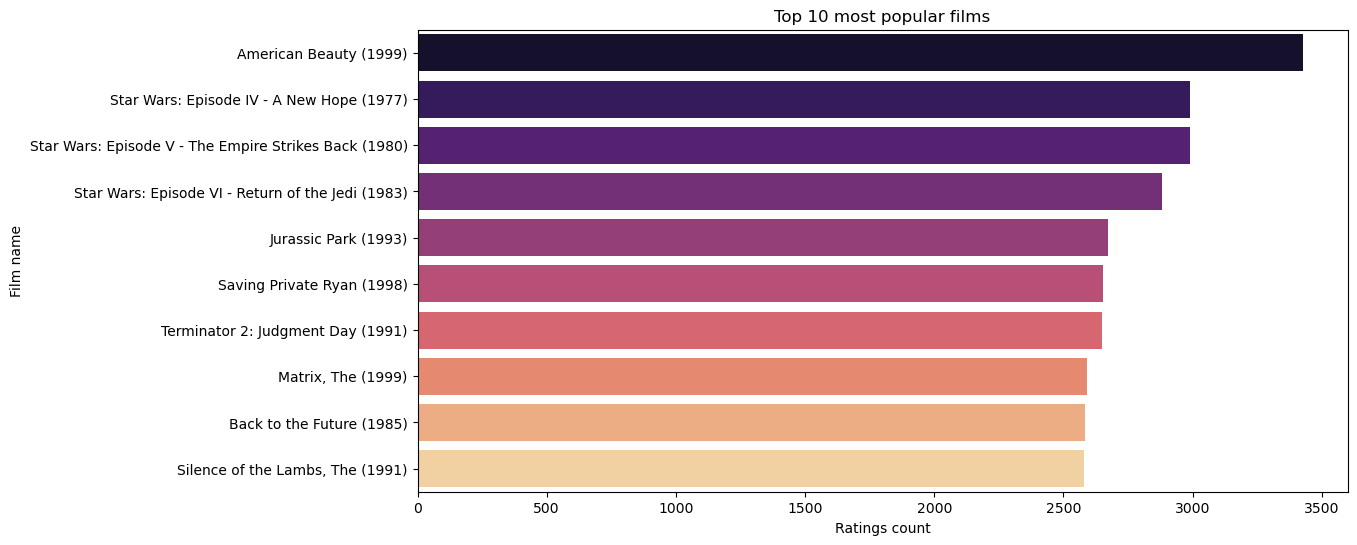

In [5]:
top_movies = df.groupby(['title'])['rating'].count().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(y=top_movies.index, x=top_movies.values, palette='magma')
plt.title('Top 10 most popular films')
plt.xlabel('Ratings count')
plt.ylabel('Film name')
plt.show()

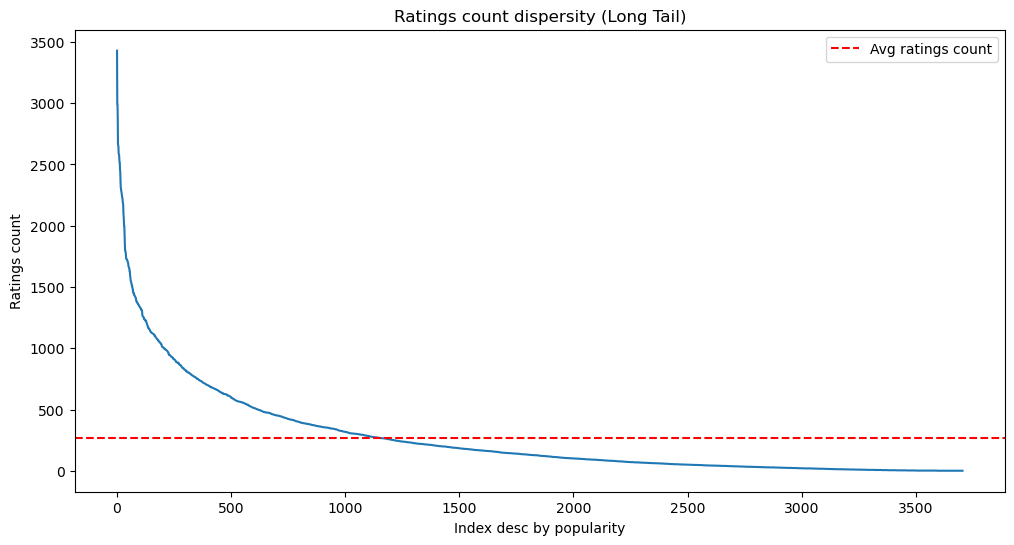

In [6]:
movie_counts = df.groupby('movieId')['rating'].count().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
plt.plot(movie_counts.values)
plt.axhline(y=movie_counts.mean(), color='r', linestyle='--', label='Avg ratings count')
plt.title('Ratings count dispersity (Long Tail)')
plt.xlabel('Index desc by popularity')
plt.ylabel('Ratings count')
plt.legend()
plt.show()

In [7]:
movie_stats = df.groupby('title').agg({'rating': ['mean', 'count']})
movie_stats.columns = ['avg_rating', 'rating_counts']

print(movie_stats.head())

                               avg_rating  rating_counts
title                                                   
$1,000,000 Duck (1971)           3.027027             37
'Night Mother (1986)             3.371429             70
'Til There Was You (1997)        2.692308             52
'burbs, The (1989)               2.910891            303
...And Justice for All (1979)    3.713568            199


<Figure size 1200x800 with 0 Axes>

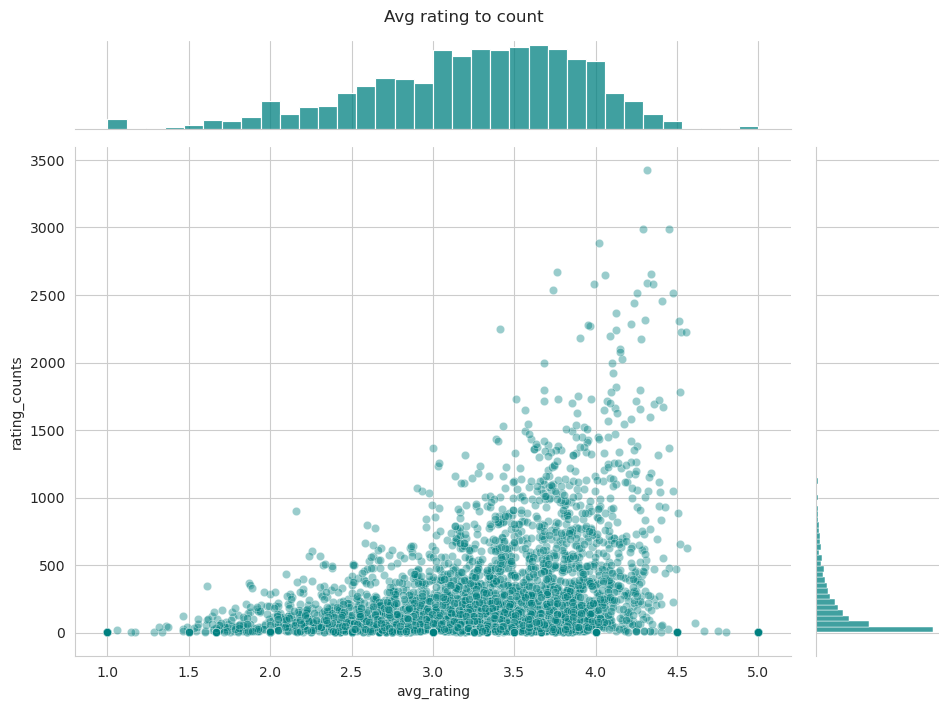

In [8]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')

g = sns.jointplot(x='avg_rating', y='rating_counts', data=movie_stats, alpha=0.4, color='teal')
g.fig.set_size_inches(10, 7)
g.fig.suptitle('Avg rating to count', y=1.02)
plt.show()

In [9]:
popular_movies = movie_stats[movie_stats["rating_counts"] > 100]
print("Top 10 popular movies by rating")
print(popular_movies.sort_values(by="avg_rating", ascending=False).head(10))

Top 10 popular movies by rating
                                                    avg_rating  rating_counts
title                                                                        
Seven Samurai (The Magnificent Seven) (Shichini...    4.560510            628
Shawshank Redemption, The (1994)                      4.554558           2227
Godfather, The (1972)                                 4.524966           2223
Close Shave, A (1995)                                 4.520548            657
Usual Suspects, The (1995)                            4.517106           1783
Schindler's List (1993)                               4.510417           2304
Wrong Trousers, The (1993)                            4.507937            882
Sunset Blvd. (a.k.a. Sunset Boulevard) (1950)         4.491489            470
Raiders of the Lost Ark (1981)                        4.477725           2514
Rear Window (1954)                                    4.476190           1050


In [10]:
popular_movies_titles = popular_movies.index
df_filtered = df[df["title"].isin(popular_movies_titles)]
user_movie_matrix = df_filtered.pivot_table(index="userId", columns="title", values="rating")
user_movie_matrix_filled = user_movie_matrix.fillna(0)
print(f"Matrix shape: {user_movie_matrix_filled.shape}")

Matrix shape: (6040, 2006)


In [11]:
item_similarity = cosine_similarity(user_movie_matrix_filled.T)
item_similarity_df = pd.DataFrame(item_similarity, 
                                  index=user_movie_matrix_filled.columns, 
                                  columns=user_movie_matrix_filled.columns)

In [12]:
def get_similar_movies(movie_title, n_recommendations=5):
    if movie_title not in item_similarity_df:
        print("No movies were found")
        return []
    recommendations = item_similarity_df[movie_title].sort_values(ascending=False).iloc[1:n_recommendations+1]
    return recommendations

test_movie = "Godfather, The (1972)"
print(f"\nTop 5 movies similar to '{test_movie}':")
print(get_similar_movies(test_movie))


Top 5 movies similar to 'Godfather, The (1972)':
title
Godfather: Part II, The (1974)                           0.769638
Star Wars: Episode IV - A New Hope (1977)                0.603362
Star Wars: Episode V - The Empire Strikes Back (1980)    0.593070
Raiders of the Lost Ark (1981)                           0.588626
Fargo (1996)                                             0.576499
Name: Godfather, The (1972), dtype: float64


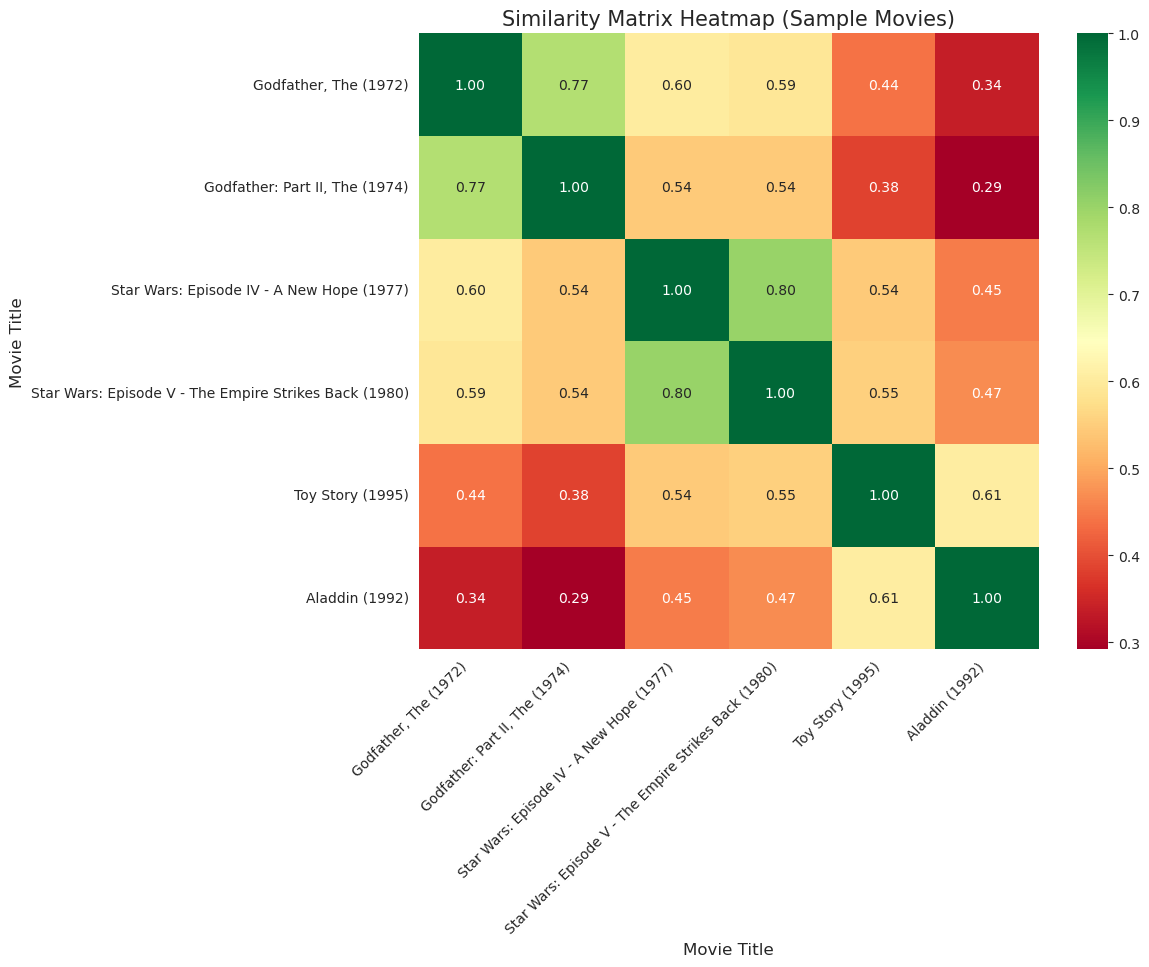

In [13]:
sample_movies = [
    "Godfather, The (1972)", 
    "Godfather: Part II, The (1974)",
    "Star Wars: Episode IV - A New Hope (1977)",
    "Star Wars: Episode V - The Empire Strikes Back (1980)",
    "Toy Story (1995)",
    "Aladdin (1992)"
]

plt.figure(figsize=(10, 8))
sns.heatmap(item_similarity_df.loc[sample_movies, sample_movies], 
            annot=True, 
            cmap='RdYlGn', 
            fmt=".2f")

plt.title('Similarity Matrix Heatmap (Sample Movies)', fontsize=15)
plt.xlabel('Movie Title', fontsize=12)
plt.ylabel('Movie Title', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.show()

In [14]:
from recommender import RecommenderEngine

engine = RecommenderEngine()
engine.item_similarity_df = item_similarity_df
engine.movie_titles = item_similarity_df.columns.tolist()
engine.save_model()

Model saved to models/movie_model.joblib


In [15]:
engine = RecommenderEngine()
engine.load_model("models/movie_model.joblib")

#Case: User wants to find something like "The Godfader" (with typo)
query = "The Godfader"
found_title = engine.find_title(query)
if found_title:
    print(f"Found: {found_title}")
    print("Recommendations:", engine.get_user_recommendations({found_title: 5}))

#Case: Recommendations based on user history from DB
user_history = {
    "Star Wars: Episode IV - A New Hope (1977)": 5.0,
    "Toy Story (1995)": 4.5,
    "Batman Forever (1995)": 2.0  # User disliked this, engine will avoid similar movies
}
recommendations = engine.get_user_recommendations(user_history)
print("\nPersonalized for User Profile:")
print(recommendations)

Model loaded successfully
Found: Godfather, The (1972)
Recommendations: title
Godfather: Part II, The (1974)                           1.924095
Star Wars: Episode IV - A New Hope (1977)                1.508405
Star Wars: Episode V - The Empire Strikes Back (1980)    1.482676
Raiders of the Lost Ark (1981)                           1.471564
Fargo (1996)                                             1.441248
dtype: float64

Personalized for User Profile:
title
Star Wars: Episode V - The Empire Strikes Back (1980)    2.913894
Star Wars: Episode VI - Return of the Jedi (1983)        2.679959
Raiders of the Lost Ark (1981)                           2.678901
Matrix, The (1999)                                       2.605115
Back to the Future (1985)                                2.604157
dtype: float64
